In [45]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers,Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
import random
import matplotlib.pyplot as plt
import matplotlib

plt.rcParams['axes.titlesize']=16
plt.rcParams['axes.labelsize']=14
plt.rcParams['image.cmap']='gray'

In [46]:
from tensorflow.keras.datasets import fashion_mnist

In [47]:
SEED_VALUE=42
random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

In [48]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()
X_valid=X_train[:10000]
y_valid=y_train[:10000]
X_train=X_train[10000:]
y_train=y_train[10000:]
print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

(50000, 28, 28)
(10000, 28, 28)
(10000, 28, 28)


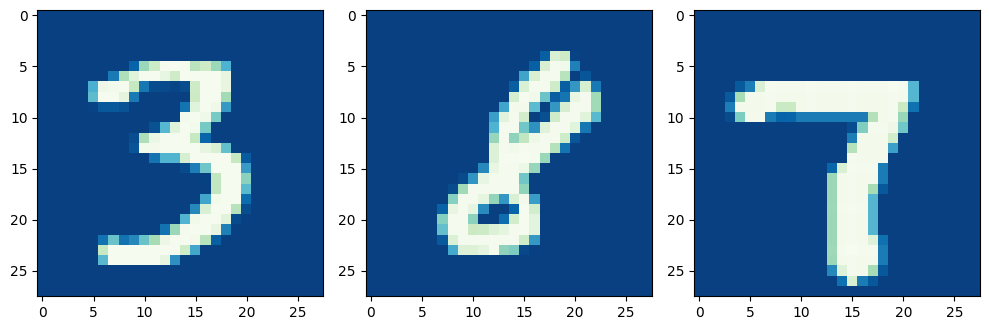

In [49]:
plt.figure(figsize=(10,10))
for i in range(3):
  plt.subplot(1,3,i+1)
  # plt.axis(True)
  plt.imshow(X_train[i],cmap='GnBu_r')
  # plt.subplots_adjust(wspace=0.2,hspace=0.2)
  plt.tight_layout()
  # plt.show()
plt.show()

In [50]:
X_train.ndim

3

In [51]:
X_train.shape

(50000, 28, 28)

In [52]:
X_train.astype

<function ndarray.astype>

In [53]:
print(X_train.dtype)

uint8


In [54]:
X_train = X_train.reshape((X_train.shape[0],28*28))
X_train = X_train.astype(float)/255

In [55]:
X_train.dtype

dtype('float64')

In [56]:
X_test=np.reshape(X_test,(X_test.shape[0],28*28)).astype(float)/255


In [57]:
X_test.shape

(10000, 784)

In [58]:
X_test.dtype

dtype('float64')

In [59]:
X_train.shape

(50000, 784)

In [60]:
X_valid = X_valid.reshape((X_valid.shape[0],28*28)).astype(float)/255

In [61]:
X_valid.shape

(10000, 784)

In [62]:
X_valid.dtype

dtype('float64')

In [63]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
y_valid = to_categorical(y_valid)
y_train.ndim

2

In [64]:
y_train.shape

(50000, 10)

In [70]:
model= Sequential()
model.add(Dense(512,activation='relu',input_shape=(X_train.shape[1],)))
model.add(Dense(256,activation='relu'))
model.add(Dense(10,activation='softmax'))

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [71]:
model.compile(optimizer='rmsprop',loss='categorical_crossentropy',metrics=['accuracy'])

In [72]:
training_results=model.fit(X_train,y_train,epochs=15,batch_size=128,validation_data=(X_valid,y_valid))

Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8526 - loss: 0.4809 - val_accuracy: 0.9582 - val_loss: 0.1334
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9673 - loss: 0.1088 - val_accuracy: 0.9701 - val_loss: 0.0966
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9810 - loss: 0.0629 - val_accuracy: 0.9700 - val_loss: 0.0988
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9879 - loss: 0.0401 - val_accuracy: 0.9716 - val_loss: 0.1036
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9925 - loss: 0.0251 - val_accuracy: 0.9709 - val_loss: 0.1160
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9945 - loss: 0.0175 - val_accuracy: 0.9769 - val_loss: 0.1001
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9960 - loss: 0.0136 - val_accuracy: 0.9776 - val_loss: 0.1063
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9970 - loss: 0.0103 - val_accuracy: 0.

In [75]:
def plot_results(metrics, title=None,ylim=None,ylabel=None,xlabel=None,metric_name=None,color=None):
  fig,ax=plt.subplots(figsize=(15,8))

  if not(isinstance(metric_name,list) or isinstance(metric_name,tuple)):
    metric_name=[metric_name,]
    metrics=metrics
  for idx,metric in enumerate(metrics):
    ax.plot(metric,color=color[idx])

  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  plt.title(title)
  plt.ylim(ylim)
  plt.legend(metric_name)
  ax.xaxis.set_major_locator(MultipleLocator(5))
  ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
  plt.grid(True)
  plt.show()
  plt.close()

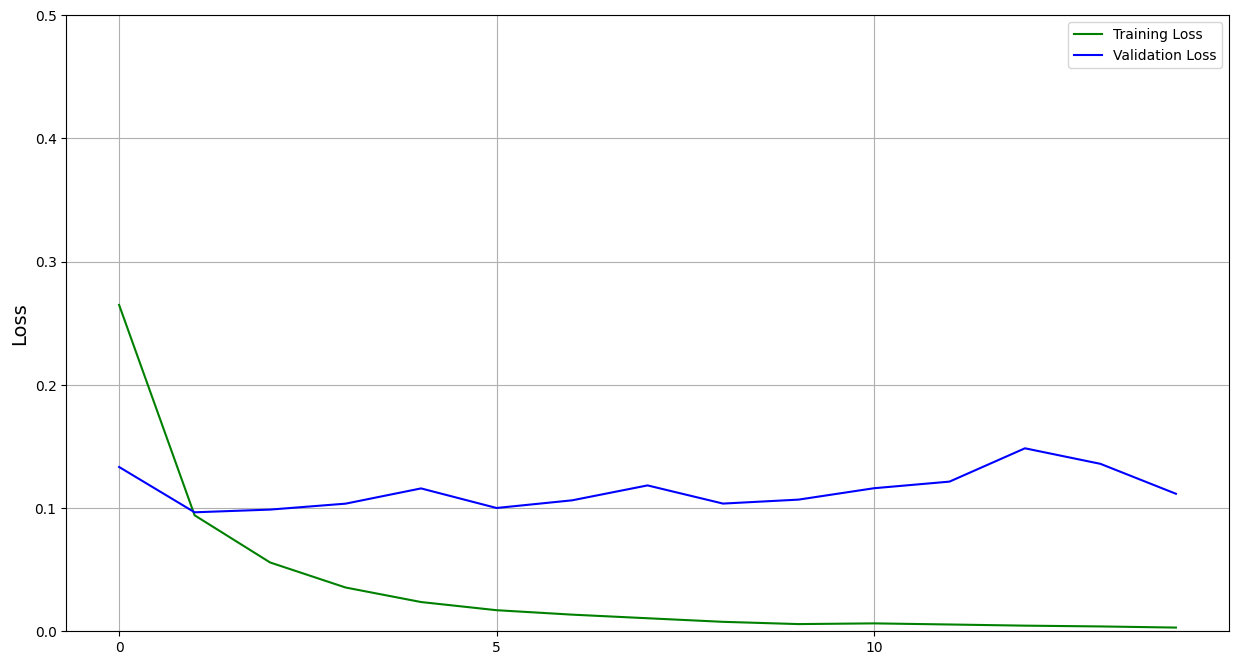

In [76]:
train_loss = training_results.history['loss']
train_acc = training_results.history['accuracy']
valid_loss = training_results.history['val_loss']
valid_acc = training_results.history['val_accuracy']

plot_results(metrics=[train_loss,valid_loss],ylabel='Loss',ylim=[0.0,0.5],metric_name=['Training Loss','Validation Loss'], color=['g','b'])

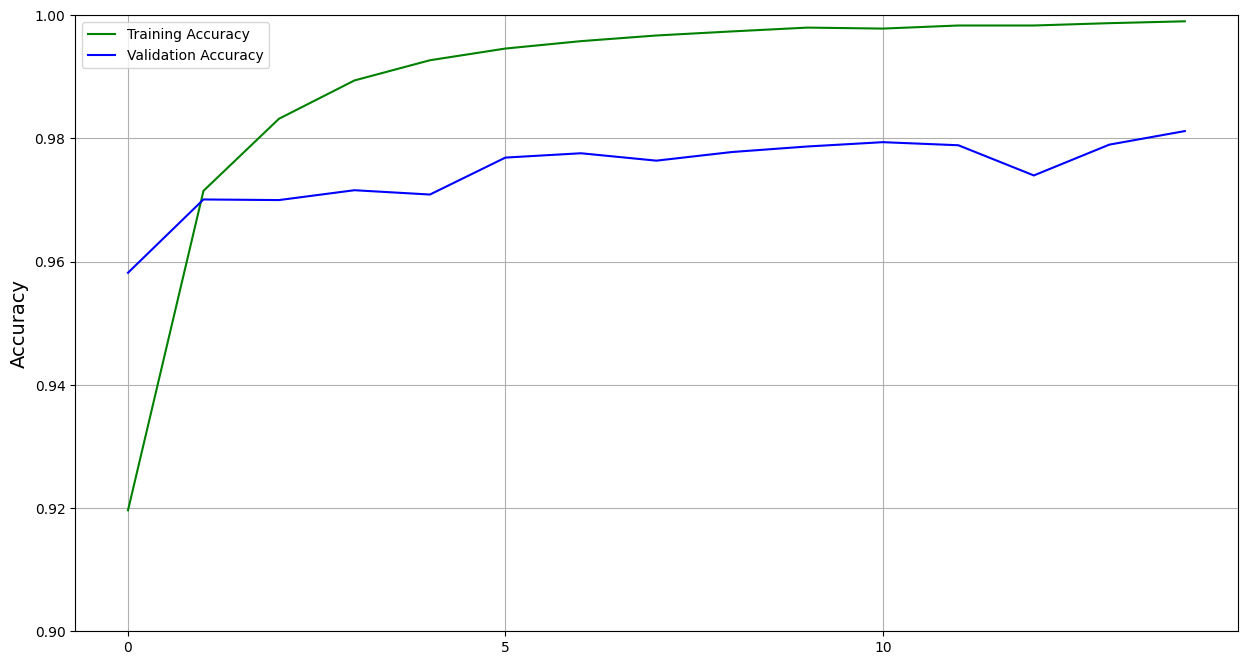

In [77]:
plot_results(metrics=[train_acc,valid_acc],ylabel='Accuracy',ylim=[0.9,1],metric_name=['Training Accuracy','Validation Accuracy'], color=['g','b'])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Y true:  7
Y predict:  7
Y prediction for each class: 
digit:  0  probability:  2.7936755e-17
digit:  1  probability:  1.3094554e-15
digit:  2  probability:  1.7161319e-16
digit:  3  probability:  1.4563311e-13
digit:  4  probability:  4.3340155e-17
digit:  5  probability:  6.09878e-18
digit:  6  probability:  2.1536026e-25
digit:  7  probability:  1.0
digit:  8  probability:  4.773363e-19
digit:  9  probability:  1.256933e-10


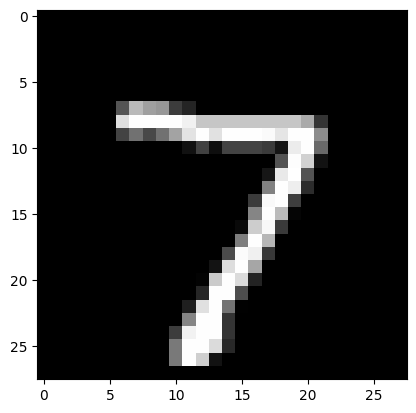

In [82]:
predictions = model.predict(X_test)
index= 0
plt.imshow(X_test[index].reshape(28,28))
print('Y true: ',np.argmax(y_test[index]))
print('Y predict: ',np.argmax(predictions[index]))
print('Y prediction for each class: ')
for i in range(10):
  print('digit: ',i,' probability: ',predictions[index][i])


In [83]:
predicted_labels=[np.argmax(i) for i in predictions]


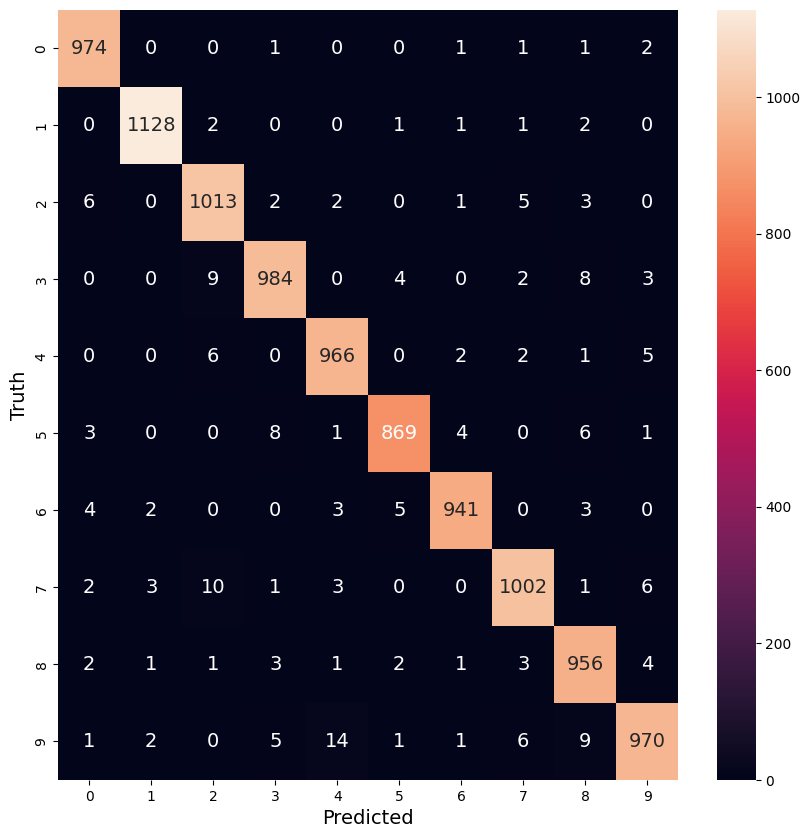

In [86]:
y_test_integer_labels=tf.argmax(y_test,axis=1)
cm=tf.math.confusion_matrix(labels=y_test_integer_labels,predictions=predicted_labels)
plt.figure(figsize=(10,10))

import seaborn as sns

sns.heatmap(cm,annot=True, fmt='d',annot_kws={'size':14})
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()